In [131]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [132]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'test': 1}

In [133]:
TEST_NUM = OPTIONS['test']
PATH     = f'../files/test{TEST_NUM}'
PATH

'../files/test1'

In [134]:
TARGET_VAR  = 'pitch'
LIMITS      = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [100, 500], 'static': [1000, 3500]}
[1000, 3500]
[100, 500]


# IMPORTANDO DADOS

In [135]:
df = pd.read_csv(f'{PATH}/reference/data.csv')
df

,sample_time,pitch,q1,time,q2,wz,q3,az,roll,ax,la_pos_mon_d,wx,wy,q0,ay,yaw
0,405000000.0,-0.003307,0.42920,0.000000,-0.5510,-0.000152,-0.5632,-0.23940,1.546,-0.02464,-0.04127,-0.000031,0.000229,0.4417,-9.787,-1.815
1,505000000.0,-0.003300,0.42920,0.056952,-0.5510,-0.000013,-0.5632,-0.23950,1.546,-0.02455,-0.04138,0.000089,-0.000004,0.4417,-9.786,-1.815
2,605000000.0,-0.003303,0.42920,0.155965,-0.5510,0.000158,-0.5632,-0.23960,1.546,-0.02456,-0.04150,-0.000140,0.000140,0.4417,-9.786,-1.815
3,705000000.0,-0.003296,0.42920,0.260658,-0.5510,0.000014,-0.5632,-0.23980,1.546,-0.02451,-0.04161,-0.000076,-0.000081,0.4417,-9.786,-1.815
4,805000000.0,-0.003288,0.42920,0.364186,-0.5510,-0.000263,-0.5632,-0.23950,1.546,-0.02439,-0.04172,0.000133,0.000234,0.4417,-9.786,-1.815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37051,505000000.0,-0.116000,0.09518,3705.261301,-0.7021,0.000297,-0.6836,0.03961,1.575,-0.34640,0.03006,-0.000227,-0.000667,0.1751,-9.782,-2.757
37052,605000000.0,-0.116000,0.09515,3705.360156,-0.7021,0.000320,-0.6836,0.03907,1.575,-0.34630,0.03022,0.000371,-0.000783,0.1751,-9.782,-2.757
37053,705000000.0,-0.116000,0.09512,3705.451226,-0.7022,0.000374,-0.6836,0.03970,1.575,-0.34700,0.03039,0.000473,-0.000660,0.1751,-9.783,-2.757
37054,805000000.0,-0.116100,0.09510,3705.561126,-0.7022,0.000162,-0.6836,0.04101,1.575,-0.34760,0.03055,0.000233,-0.000748,0.1750,-9.784,-2.757


- Convertendo pra radianos

In [136]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,sample_time,pitch,q1,time,q2,wz,q3,az,roll,ax,la_pos_mon_d,wx,wy,q0,ay,yaw
0,405000000.0,-0.189477,0.42920,0.000000,-0.5510,-0.008692,-0.5632,-0.23940,88.579275,-0.02464,-0.04127,-0.001761,0.013144,0.4417,-9.787,-103.991840
1,505000000.0,-0.189076,0.42920,0.056952,-0.5510,-0.000726,-0.5632,-0.23950,88.579275,-0.02455,-0.04138,0.005117,-0.000240,0.4417,-9.786,-103.991840
2,605000000.0,-0.189248,0.42920,0.155965,-0.5510,0.009064,-0.5632,-0.23960,88.579275,-0.02456,-0.04150,-0.008016,0.008004,0.4417,-9.786,-103.991840
3,705000000.0,-0.188847,0.42920,0.260658,-0.5510,0.000827,-0.5632,-0.23980,88.579275,-0.02451,-0.04161,-0.004338,-0.004637,0.4417,-9.786,-103.991840
4,805000000.0,-0.188389,0.42920,0.364186,-0.5510,-0.015075,-0.5632,-0.23950,88.579275,-0.02439,-0.04172,0.007603,0.013424,0.4417,-9.786,-103.991840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37051,505000000.0,-6.646310,0.09518,3705.261301,-0.7021,0.017040,-0.6836,0.03961,90.240853,-0.34640,0.03006,-0.012983,-0.038233,0.1751,-9.782,-157.964464
37052,605000000.0,-6.646310,0.09515,3705.360156,-0.7021,0.018358,-0.6836,0.03907,90.240853,-0.34630,0.03022,0.021285,-0.044880,0.1751,-9.782,-157.964464
37053,705000000.0,-6.646310,0.09512,3705.451226,-0.7022,0.021406,-0.6836,0.03970,90.240853,-0.34700,0.03039,0.027107,-0.037844,0.1751,-9.783,-157.964464
37054,805000000.0,-6.652040,0.09510,3705.561126,-0.7022,0.009299,-0.6836,0.04101,90.240853,-0.34760,0.03055,0.013350,-0.042834,0.1750,-9.784,-157.964464


In [137]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,sample_time,pitch,q1,time,q2,wz,q3,az,roll,ax,la_pos_mon_d,wx,wy,q0,ay,yaw


# VISUALIZAÇÃO DE VARIÁVEIS

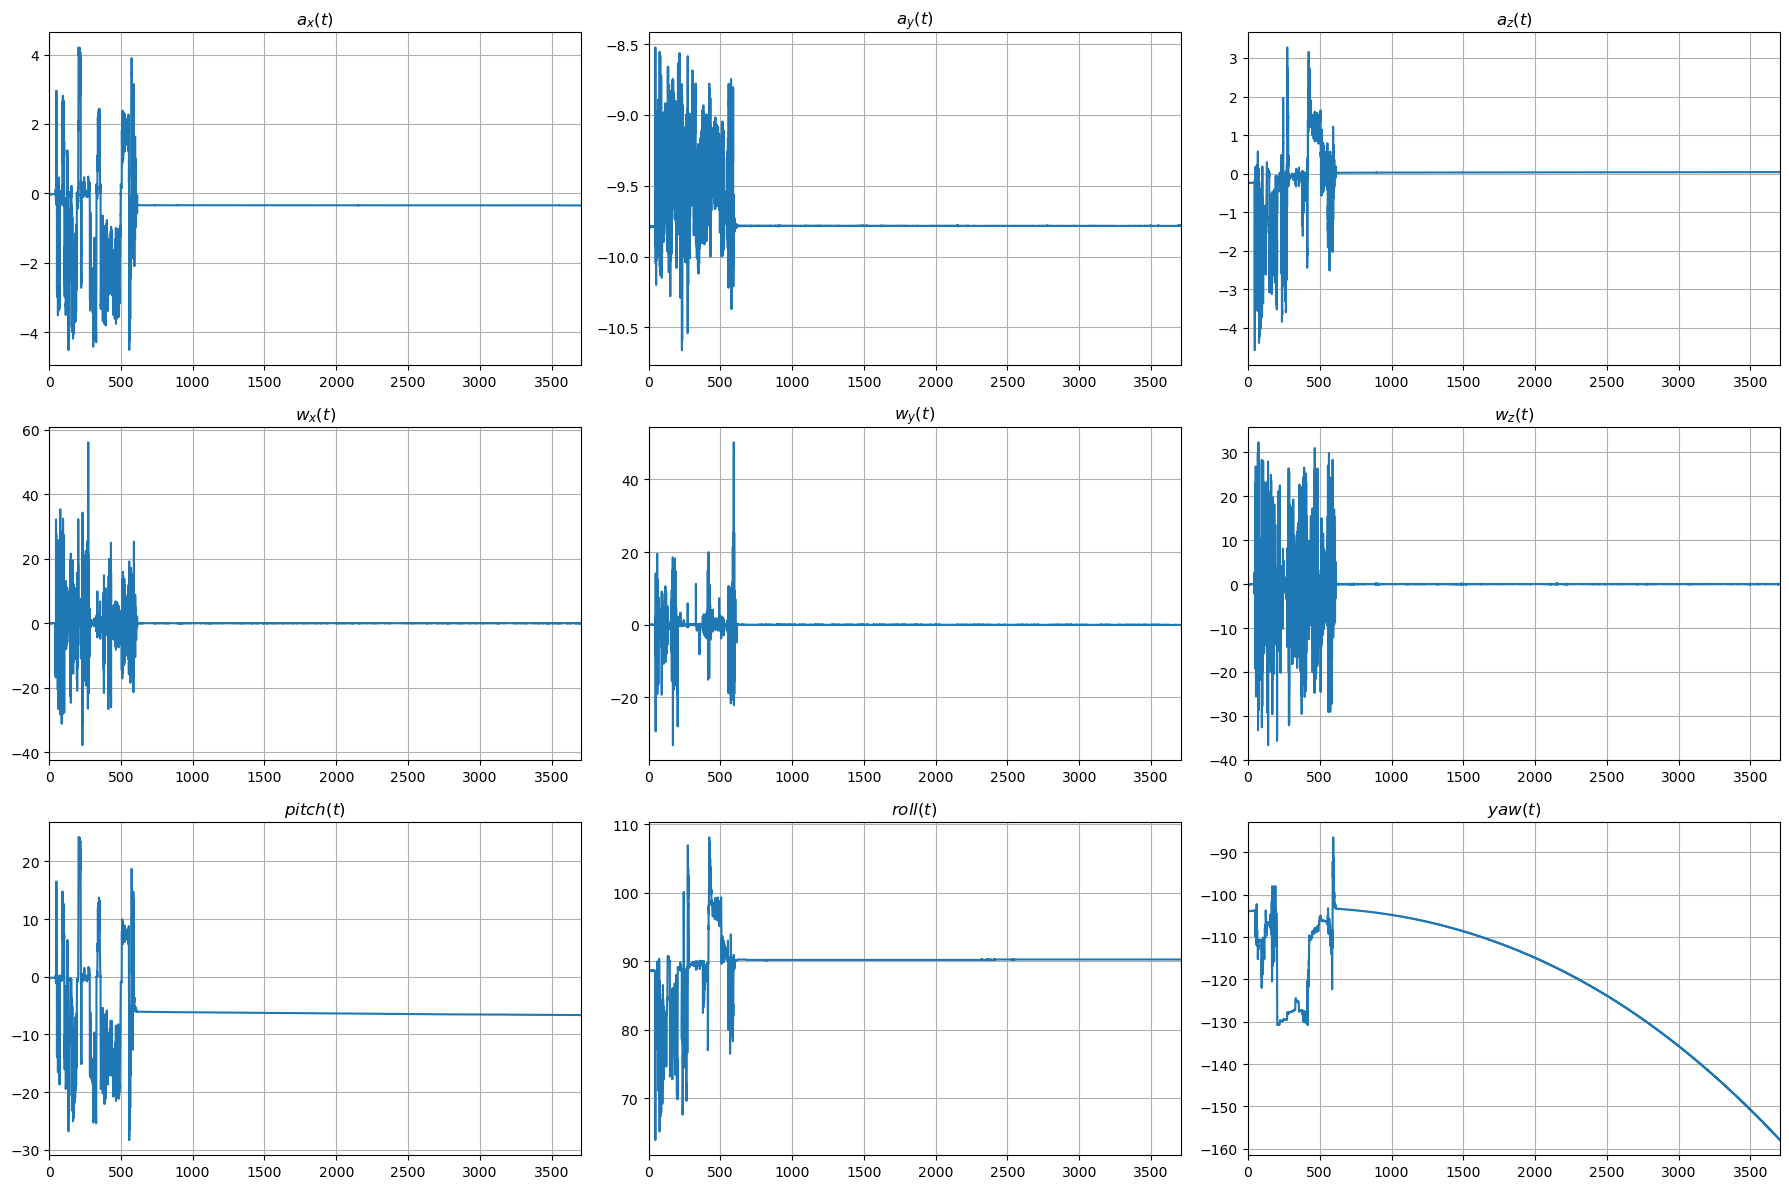

In [138]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

- Juntando Amostragem pelos limites definidos

In [139]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,sample_time,pitch,q1,time,q2,wz,q3,az,roll,ax,la_pos_mon_d,wx,wy,q0,ay,yaw,static
0,505000000.0,7.098947,0.3712,0.000000,-0.5229,-27.782723,-0.6765,-2.09200,79.698429,0.7386,0.23230,27.467597,-3.705891,0.3620,-9.682,-117.742827,False
1,605000000.0,9.637150,0.3892,0.110859,-0.5312,-25.284627,-0.6735,-1.57700,82.276739,1.3800,0.23000,26.247197,-3.414256,0.3359,-9.483,-118.544968,False
2,705000000.0,11.459156,0.4032,0.212989,-0.5382,-16.512644,-0.6689,-1.21900,84.396683,1.8730,0.22960,21.382785,-0.638848,0.3166,-9.313,-118.946038,False
3,805000000.0,12.679556,0.4155,0.304652,-0.5455,-10.467939,-0.6618,-0.80840,86.516627,2.1420,0.23090,20.368650,2.102182,0.3029,-9.384,-118.888742,False
4,905000000.0,12.272756,0.4113,0.412388,-0.5444,7.746389,-0.6638,0.18610,85.943669,2.6810,0.23170,-14.358322,-3.723080,0.3063,-9.448,-119.003334,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28994,805000000.0,-6.606203,0.1390,2899.439572,-0.6948,-0.031387,-0.6714,0.03985,90.240853,-0.3455,0.05073,-0.008486,-0.034813,0.2171,-9.783,-150.802492,True
28995,905000000.0,-6.606203,0.1389,2899.538391,-0.6948,-0.010451,-0.6714,0.03972,90.240853,-0.3449,0.05080,0.002791,-0.032384,0.2171,-9.784,-150.802492,True
28996,5000000.0,-6.611933,0.1389,2899.631941,-0.6948,0.008789,-0.6714,0.03956,90.240853,-0.3449,0.05088,-0.002540,-0.028390,0.2171,-9.783,-150.802492,True
28997,105000000.0,-6.606203,0.1389,2899.740079,-0.6948,-0.000646,-0.6714,0.03989,90.240853,-0.3453,0.05095,-0.016742,-0.033346,0.2171,-9.783,-150.802492,True


# AMOSTRAGEM

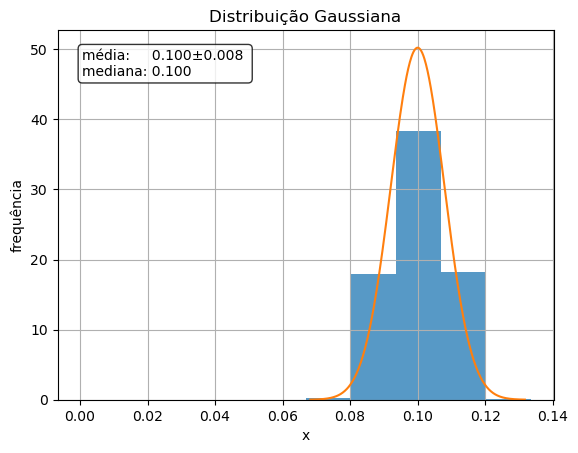

In [140]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time)

In [141]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,sample_time,pitch,q1,q2,wz,q3,az,roll,ax,la_pos_mon_d,wx,wy,q0,ay,yaw,static
0,0.0,505000000.0,7.098947,0.3712,-0.5229,-27.782723,-0.6765,-2.09200,79.698429,0.7386,0.23230,27.467597,-3.705891,0.3620,-9.682,-117.742827,False
1,0.1,505000000.0,7.098947,0.3712,-0.5229,-27.782723,-0.6765,-2.09200,79.698429,0.7386,0.23230,27.467597,-3.705891,0.3620,-9.682,-117.742827,False
2,0.2,605000000.0,9.637150,0.3892,-0.5312,-25.284627,-0.6735,-1.57700,82.276739,1.3800,0.23000,26.247197,-3.414256,0.3359,-9.483,-118.544968,False
3,0.3,705000000.0,11.459156,0.4032,-0.5382,-16.512644,-0.6689,-1.21900,84.396683,1.8730,0.22960,21.382785,-0.638848,0.3166,-9.313,-118.946038,False
4,0.4,805000000.0,12.679556,0.4155,-0.5455,-10.467939,-0.6618,-0.80840,86.516627,2.1420,0.23090,20.368650,2.102182,0.3029,-9.384,-118.888742,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28995,2899.5,805000000.0,-6.606203,0.1390,-0.6948,-0.031387,-0.6714,0.03985,90.240853,-0.3455,0.05073,-0.008486,-0.034813,0.2171,-9.783,-150.802492,True
28996,2899.6,905000000.0,-6.606203,0.1389,-0.6948,-0.010451,-0.6714,0.03972,90.240853,-0.3449,0.05080,0.002791,-0.032384,0.2171,-9.784,-150.802492,True
28997,2899.7,5000000.0,-6.611933,0.1389,-0.6948,0.008789,-0.6714,0.03956,90.240853,-0.3449,0.05088,-0.002540,-0.028390,0.2171,-9.783,-150.802492,True
28998,2899.8,105000000.0,-6.606203,0.1389,-0.6948,-0.000646,-0.6714,0.03989,90.240853,-0.3453,0.05095,-0.016742,-0.033346,0.2171,-9.783,-150.802492,True


# FILTRANDO POR VARIAVEL

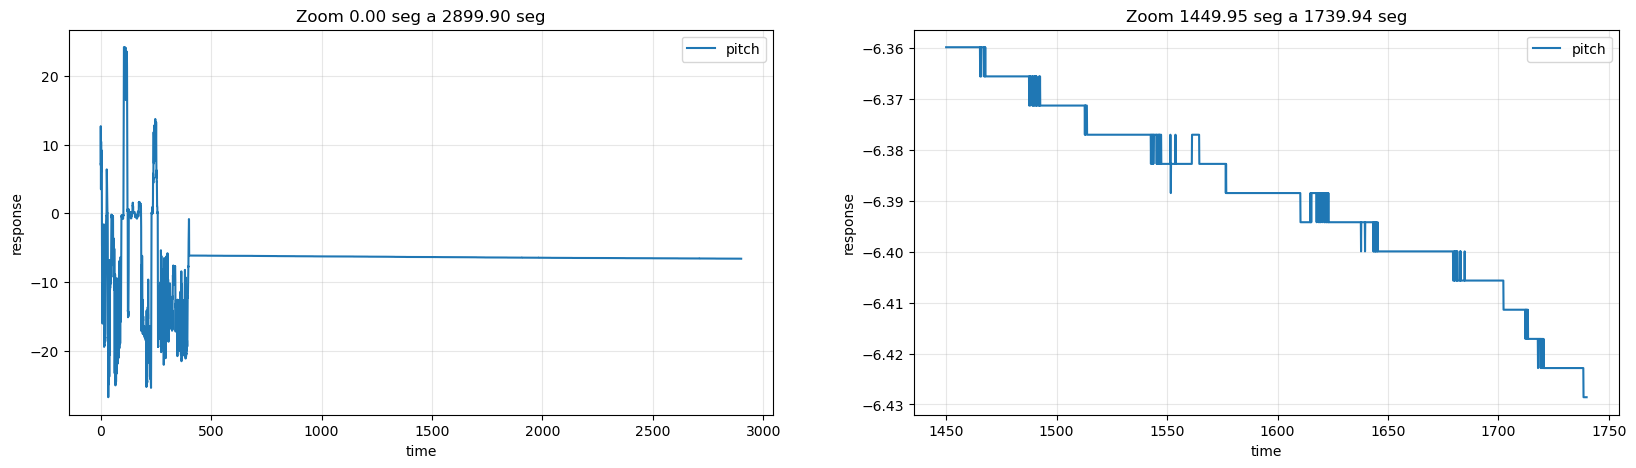

In [142]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [143]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,ref_sample_time,ref_pitch,ref_q1,ref_q2,ref_wz,ref_q3,ref_az,ref_roll,ref_ax,ref_la_pos_mon_d,ref_wx,ref_wy,ref_q0,ref_ay,ref_yaw,static
0,0.0,505000000.0,7.098947,0.3712,-0.5229,-27.782723,-0.6765,-2.09200,79.698429,0.7386,0.23230,27.467597,-3.705891,0.3620,-9.682,-117.742827,False
1,0.1,505000000.0,7.098947,0.3712,-0.5229,-27.782723,-0.6765,-2.09200,79.698429,0.7386,0.23230,27.467597,-3.705891,0.3620,-9.682,-117.742827,False
2,0.2,605000000.0,9.637150,0.3892,-0.5312,-25.284627,-0.6735,-1.57700,82.276739,1.3800,0.23000,26.247197,-3.414256,0.3359,-9.483,-118.544968,False
3,0.3,705000000.0,11.459156,0.4032,-0.5382,-16.512644,-0.6689,-1.21900,84.396683,1.8730,0.22960,21.382785,-0.638848,0.3166,-9.313,-118.946038,False
4,0.4,805000000.0,12.679556,0.4155,-0.5455,-10.467939,-0.6618,-0.80840,86.516627,2.1420,0.23090,20.368650,2.102182,0.3029,-9.384,-118.888742,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28995,2899.5,805000000.0,-6.606203,0.1390,-0.6948,-0.031387,-0.6714,0.03985,90.240853,-0.3455,0.05073,-0.008486,-0.034813,0.2171,-9.783,-150.802492,True
28996,2899.6,905000000.0,-6.606203,0.1389,-0.6948,-0.010451,-0.6714,0.03972,90.240853,-0.3449,0.05080,0.002791,-0.032384,0.2171,-9.784,-150.802492,True
28997,2899.7,5000000.0,-6.611933,0.1389,-0.6948,0.008789,-0.6714,0.03956,90.240853,-0.3449,0.05088,-0.002540,-0.028390,0.2171,-9.783,-150.802492,True
28998,2899.8,105000000.0,-6.606203,0.1389,-0.6948,-0.000646,-0.6714,0.03989,90.240853,-0.3453,0.05095,-0.016742,-0.033346,0.2171,-9.783,-150.802492,True


In [144]:
df.to_csv('data.csv', index=None)